In [ ]:
from google.colab import drive
drive.mount("/content/gdrive/")
import os
os.chdir("/content/gdrive/My Drive/MultimodalEmotion/MODULE3")
!ls

Mounted at /content/gdrive/
extracted_text.txt  SentimentAnalyser.h5      text_emotion.npy
LSTM_model.ipynb    SentimentAnalyser_old.h5
LSTM_new.ipynb	    text_emotion.csv


In [ ]:
#%cd drive/MyDrive/"Colab Notebooks"
#!ls

<h1>Importing <b>NLTK Library</b> </h1>

In [ ]:
import nltk
#nltk.download()
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem.wordnet import WordNetLemmatizer

<h2>Importing Necessary Libraries</h2>

In [ ]:
!pip install Keras-Preprocessing

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 1.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Dropout, Embedding, LSTM, SpatialDropout1D
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
#loading text emotion dataset
data = pd.read_csv('text_emotion.csv')

print(data.shape)

#removing unwanted instances in dataset
data.drop(data.index[(data["Emotion"] == "guit")],axis=0,inplace=True)

(7516, 2)


In [ ]:
data = data.sample(frac=1, random_state=1).reset_index()
data.head()

,index,Emotion,Text
0,5695,joy,After being depressed because of a very bad re...
1,946,fear,"In Sweden, a friend and I lived in an appartme..."
2,5135,disgust,One evening when a boy who was drunk made a pa...
3,984,disgust,"A series about Freud was shown on TV. In it, ..."
4,802,fear,"The house was on fire, and I was saved by the ..."


<h1>Preprocessing, Stemming And Lemming</h1>

In [ ]:
X_text_feature = data['Text']  # This will be your input feature (X)
Y_labels = data['Emotion']    # This will be your target label (Y)

x = []
stop_words=set(stopwords.words("english"))
ps = PorterStemmer()
lem = WordNetLemmatizer()

for ent in X_text_feature:

    # Word Tokenization
    tokenized_text=word_tokenize(ent)

    # StopWord Removal
    filtered_sent=[]
    for w in tokenized_text:
        if w not in stop_words:
            filtered_sent.append(w)

    # Stemming And Lemming
    stemmed_words=[]
    lemmed_words=[]
    for u in filtered_sent:
        stemmed_words.append(ps.stem(u))
        lemmed_words.append(lem.lemmatize(u))


    # filtering all the punctuations
    import string
    table = str.maketrans('', '', string.punctuation)
    stripped = [v.translate(table) for v in lemmed_words]
    words = [word for word in stripped if word.isalpha()]

    clean_text = ''
    for z in words:
        clean_text += ' ' + z

    x.append(clean_text)

In [ ]:
data['clean_tweet'] = x
data['tweet_len'] = data['clean_tweet'].apply(len)
data.head()

,index,Emotion,Text,clean_tweet,tweet_len
0,5695,joy,After being depressed because of a very bad re...,After depressed bad relationship first love c...,83
1,946,fear,"In Sweden, a friend and I lived in an appartme...",In Sweden friend I lived appartment owned Fin...,182
2,5135,disgust,One evening when a boy who was drunk made a pa...,One evening boy drunk made pas trying kiss,43
3,984,disgust,"A series about Freud was shown on TV. In it, ...",A series Freud shown TV In tampon set nose wo...,124
4,802,fear,"The house was on fire, and I was saved by the ...",The house fire I saved dog I afraid fire verg...,55


<Axes: xlabel='Emotion'>

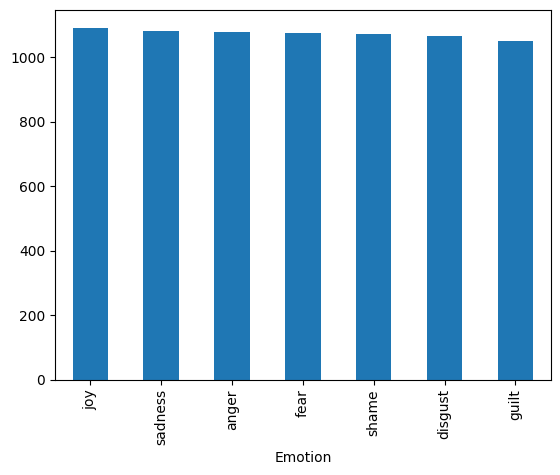

In [ ]:
data['Emotion'].value_counts().plot(kind='bar', stacked=False)

In [ ]:
data['clean_tweet'].values

array([' After depressed bad relationship first love called told would always care matter I',
       ' In Sweden friend I lived appartment owned Finn One day man came back appartment heavily drunk hashish alcohol He quite dizzy broke I could foretell reaction However nothing happened',
       ' One evening boy drunk made pas trying kiss', ...,
       ' I taking shower cubicle France Then I discovered child loking adjacent cubicle',
       ' Someone vomited street',
       ' When first sexual intercourse turned flop I panic ended without erection'],
      dtype=object)

<h3>Test, Train Split</h3>

In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Convert string labels to integers (y_encoded)
encoder = LabelEncoder()
Y_encoded = encoder.fit_transform(data['Emotion']) # Use your original label column!

# Convert integer labels to one-hot encoding
Y = to_categorical(Y_encoded)

from sklearn.model_selection import train_test_split


X_text = data['clean_tweet'].values


X_train_raw, X_test_raw, Y_train, Y_test = train_test_split(
    X_text,
    Y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(data['tweet_len'].describe())
truncated_percentage = (data['tweet_len'] > 32).sum() / len(data) * 100
print(f"\nPercentage of samples currently truncated at maxlen=32: {truncated_percentage:.2f}%")

count    7515.000000
mean       73.531870
std        45.458351
min         5.000000
25%        40.000000
50%        63.000000
75%        96.000000
max       527.000000
Name: tweet_len, dtype: float64

Percentage of samples currently truncated at maxlen=32: 84.64%


In [ ]:
max_words = 2000
tokenizer = Tokenizer(num_words=max_words, split=' ')
tokenizer.fit_on_texts(X_train_raw)
X_train = tokenizer.texts_to_sequences(X_train_raw)
X_test = tokenizer.texts_to_sequences(X_test_raw)
X_train = pad_sequences(X_train, maxlen=64)
X_test = pad_sequences(X_test, maxlen=64)

In [ ]:
Y[-15:-1]

array([[1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0., 0., 0.]])

In [ ]:
dict_emotion = {}
dict_label = {}
for i in range(len(Y)):
    dict_emotion[data['Emotion'][i]] = np.argmax(Y[i])
    dict_label[np.argmax(Y[i])] = data['Emotion'][i]
    if len(dict_emotion) == 7:
        print('Break at: ', i)
        break

print(dict_emotion, dict_label)

Break at:  12
{'joy': np.int64(4), 'fear': np.int64(2), 'disgust': np.int64(1), 'shame': np.int64(6), 'anger': np.int64(0), 'sadness': np.int64(5), 'guilt': np.int64(3)} {np.int64(4): 'joy', np.int64(2): 'fear', np.int64(1): 'disgust', np.int64(6): 'shame', np.int64(0): 'anger', np.int64(5): 'sadness', np.int64(3): 'guilt'}


In [ ]:
X_val = X_train[:5000]
Y_val = Y_train[:5000]
partial_X_train = X_train[5000:]
partial_Y_train = Y_train[5000:]

In [ ]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1])
print(X_train.shape,Y_train.shape)
print(X_test.shape,Y_test.shape)

(6012, 64) (6012, 7)
(1503, 64) (1503, 7)


<h2>Hyperparameter Adjustment and Model Initialisation</h2>

In [ ]:
embedding_out_dim = 256
lstm_out_dim = 256

model = Sequential()
model.add(Embedding(max_words, embedding_out_dim, input_length=64))
model.add(SpatialDropout1D(0.5))
model.add(LSTM(lstm_out_dim,  return_sequences=False))
model.add(Dense(7,activation='softmax'))
model.compile(loss = 'categorical_crossentropy', optimizer='adam',metrics = ['accuracy'])


checkpoint_filepath = 'best_emotion_model_maxlen64.h5'

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=1,
    mode='min',
    restore_best_weights=True
)

model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_loss',
    save_best_only=True,
    mode='min'
)
my_callbacks = [early_stopping_callback, model_checkpoint_callback]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


<h2>Fitting the Model and Validation</h2>

In [ ]:

print(X_train.shape)
print(Y_train.shape)

batch_size = 64
history = model.fit(X_train,Y_train, epochs = 10, batch_size=batch_size, validation_data=(X_val, Y_val), callbacks=my_callbacks)

(6012, 64)
(6012, 7)
Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.6844 - loss: 0.9369

94/94 ━━━━━━━━━━━━━━━━━━━━ 61s 652ms/step - accuracy: 0.6843 - loss: 0.9369 - val_accuracy: 0.7668 - val_loss: 0.7364
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - accuracy: 0.7546 - loss: 0.7536

94/94 ━━━━━━━━━━━━━━━━━━━━ 70s 748ms/step - accuracy: 0.7544 - loss: 0.7538 - val_accuracy: 0.8160 - val_loss: 0.5819
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.7955 - loss: 0.6182

94/94 ━━━━━━━━━━━━━━━━━━━━ 81s 744ms/step - accuracy: 0.7953 - loss: 0.6186 - val_accuracy: 0.8400 - val_loss: 0.5092
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 545ms/step - accuracy: 0.8106 - loss: 0.5711

94/94 ━━━━━━━━━━━━━━━━━━━━ 73s 777ms/step - accuracy: 0.8105 - loss: 0.5713 - val_accuracy: 0.8590 - val_loss: 0.4495
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 516ms/step - accuracy: 0.8386 - loss: 0.4912

...

94/94 ━━━━━━━━━━━━━━━━━━━━ 71s 762ms/step - accuracy: 0.8531 - loss: 0.4373 - val_accuracy: 0.8952 - val_loss: 0.3368
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 532ms/step - accuracy: 0.8741 - loss: 0.4005

94/94 ━━━━━━━━━━━━━━━━━━━━ 63s 672ms/step - accuracy: 0.8740 - loss: 0.4007 - val_accuracy: 0.9126 - val_loss: 0.2863
Epoch 8/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.8839 - loss: 0.3555

94/94 ━━━━━━━━━━━━━━━━━━━━ 77s 621ms/step - accuracy: 0.8838 - loss: 0.3558 - val_accuracy: 0.9166 - val_loss: 0.2683
Epoch 9/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 516ms/step - accuracy: 0.8908 - loss: 0.3370

94/94 ━━━━━━━━━━━━━━━━━━━━ 70s 746ms/step - accuracy: 0.8907 - loss: 0.3371 - val_accuracy: 0.9296 - val_loss: 0.2384
Epoch 10/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 545ms/step - accuracy: 0.8893 - loss: 0.3067

94/94 ━━━━━━━━━━━━━━━━━━━━ 64s 682ms/step - accuracy: 0.8892 - loss: 0.3070 - val_accuracy: 0.9330 - val_loss: 0.2144
Restoring model weights from the end of the best epoch: 10.


In [ ]:
# # # Save the model
model.save('SentimentAnalyser.h5')

In [ ]:
from keras.models import load_model

model = load_model('best_emotion_model_maxlen64.h5')
print("Model restored from best epoch.")


Model restored from best epoch.


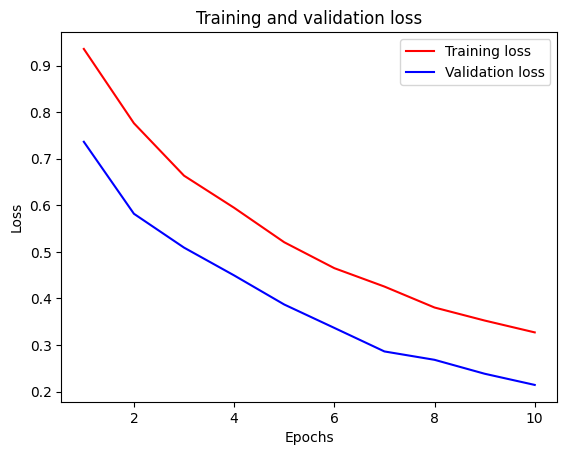

In [ ]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
predict = model.predict(X_test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step


In [ ]:
emotion_Y_predicted = np.zeros(predict.shape)

for i in range (0,len(predict)):
    u = predict[i]
    v = np.argmax(u)
    emotion_Y_predicted[i][v] = 1

In [ ]:
correct_count = 0
total_count = 0

for j in range(0, predict.shape[0]):

    total_count += 1

    if np.array_equal(Y_test[j], emotion_Y_predicted[j]) == True:

        correct_count += 1

In [ ]:
print("Correct Count : ", correct_count)
print("\nTotal Count : ", total_count)

Correct Count :  810

Total Count :  1503


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

y_true_labels = np.argmax(Y_test, axis=1)
y_pred_labels = np.argmax(emotion_Y_predicted, axis=1)


print("Accuracy Score : ", accuracy_score(y_true_labels, y_pred_labels))
print("F1 Score (Weighted) : ", f1_score(y_true_labels, y_pred_labels, average='weighted'))

Accuracy Score :  0.5389221556886228
F1 Score (Weighted) :  0.5353861047071174


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true_labels, y_pred_labels))
print("\n--- CONFUSION MATRIX ---")
cm = confusion_matrix(y_true_labels, y_pred_labels)
print(cm)


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.41      0.41      0.41       218
           1       0.51      0.56      0.53       178
           2       0.65      0.68      0.67       214
           3       0.47      0.42      0.44       227
           4       0.60      0.74      0.66       232
           5       0.64      0.54      0.59       224
           6       0.47      0.41      0.44       210

    accuracy                           0.54      1503
   macro avg       0.54      0.54      0.53      1503
weighted avg       0.54      0.54      0.54      1503


--- CONFUSION MATRIX ---
[[ 89  30  21  28  16  17  17]
 [ 27 100  10   8  11  10  12]
 [ 18   9 146  10  16   4  11]
 [ 30  16   8  96  27  17  33]
 [ 13  10  13   7 171   9   9]
 [ 15   9  15  17  30 121  17]
 [ 24  23  11  40  15  10  87]]


In [ ]:
def preprocess(input):
    words = word_tokenize(input)
    stop_removed_words = []
    punc_removed_words = []
    lemmed_words = []

    for word in words:
        if word not in stop_words:
            stop_removed_words.append(word)

    table1 = str.maketrans('', '', string.punctuation)
    stripped = [v.translate(table1) for v in stop_removed_words]
    punc_removed_words = [word for word in stripped if word.isalpha()]

    for pun_word in punc_removed_words:
        lemmed_words.append(lem.lemmatize(pun_word))

    clean_text = ''
    for z in lemmed_words:
        clean_text += ' ' + z

    return clean_text

In [ ]:
MAXLEN = 64

def getInput(ud):

    final_obj_local = [preprocess(i) for i in ud]

    X_input = tokenizer.texts_to_sequences(final_obj_local)
    X_input = pad_sequences(X_input, maxlen=MAXLEN)

    predict = model.predict(X_input)
    emotion_Y_predicted_local = np.zeros(predict.shape)
    for i in range (0,len(predict)):
        v = np.argmax(predict[i])
        emotion_Y_predicted_local[i][v] = 1


    predicted_emotion = dict_label.get(np.argmax(emotion_Y_predicted_local[-1]))
    print("Input  : " , final_obj_local[-1], "\nOutput : ", predicted_emotion, "\n\n" )

    return final_obj_local, emotion_Y_predicted_local

In [ ]:
filename = 'extracted_text.txt'
with open(filename, 'r') as file:
    file_contents = file.read()
ud = []
ud.append(file_contents)

clean_input_list, predicted_one_hot_array = getInput(ud)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Input  :   
Output :  joy 




In [ ]:
print("Input  : " , clean_input_list[0],
      "\nOutput : ", dict_label.get(np.argmax(predicted_one_hot_array[0])),
      "\n\n" )

Input  :   
Output :  joy 




In [ ]:
print("Classified Emotion: ", dict_label.get(np.argmax(predicted_one_hot_array[0])));

Classified Emotion:  joy
